## Late Night Drives

Driving at night presents unique dangers for drivers. Reduced visibility, glare from headlights, fatigue, poorly lit roadways, substance abuse... the possibilities are unfortunately endeless. While these risks affect everyone, they may pose particular challenges for older drivers. Vision naturally deteriorates with age, making it more difficult to see in low-light conditions, judge distance, and react quickly to hazards on the road.

Because of this, it is important to examine whether older drivers are disproportionately involved in nighttime crashes compared to younger drivers. To begin exploring this question, we will first examine how frequently crashes occur at night across several older age groups. The table below shows the share of crashes that occurred during nighttime conditions for drivers between the ages of 50–64, 65–74, and 75 and older.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
crash_data = pd.read_csv('../../08_DOW4_and_Geolocated_data_with_GeoPandas/data/PDOT_crash_data_2005_2024.csv', low_memory=False)
flag = pd.read_csv('../../09b_DOW4/data/PDOT_flag_data_2005_2024.csv', low_memory=False)

crash_age = crash_data.merge(flag, on="CRN", how="inner")
crash_joined = crash_data.merge(flag, on="CRN", how="inner")

crash_age["night_crash"] = crash_age["ILLUMINATION_DARK"]

crash_age["age_group"] = pd.Series(dtype="object")

crash_age.loc[crash_age["DRIVER_50_64YR"] == 1, "age_group"] = "50–64"
crash_age.loc[crash_age["DRIVER_65_74YR"] == 1, "age_group"] = "65–74"
crash_age.loc[crash_age["DRIVER_75PLUS"] == 1, "age_group"] = "75+"

crash_age["older_driver"] = np.where(
    (crash_age["DRIVER_50_64YR"] == 1) |
    (crash_age["DRIVER_65_74YR"] == 1) |
    (crash_age["DRIVER_75PLUS"] == 1),
    "Older (50+)",
    "Under 50"
)

crash_age = crash_age[
    crash_age["age_group"].isin(["50–64", "65–74", "75+"])
]

/tmp/ipykernel_2617590/1397839531.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  crash_age["night_crash"] = crash_age["ILLUMINATION_DARK"]
/tmp/ipykernel_2617590/1397839531.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  crash_age["age_group"] = pd.Series(dtype="object")
/tmp/ipykernel_2617590/1397839531.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inst

In [3]:
age_table = (
    crash_age
    .groupby("age_group")["night_crash"]
    .agg(["count","sum","mean"])
).round(3)

age_table["percent_night"] = age_table["mean"] * 100
age_table

,count,sum,mean,percent_night
age_group,,,,
50–64,167789,42856,0.255,25.5
65–74,57813,11277,0.195,19.5
75+,38738,5294,0.137,13.7


The table shows the proportion of crashes that occur at night for different older driver age groups. While nighttime crashes make up a relatively small share of total crashes overall, the percentage declines slightly as driver age increases. Drivers aged 50–64 experience the highest share of nighttime crashes, followed by 65–74, with drivers 75 and older having the lowest proportion.

This pattern may suggest that the oldest drivers are less likely to be on the road at night, possibly due to self-regulation or reduced nighttime driving comfort. As drivers age, they may intentionally limit driving during darker conditions when visibility is reduced and reaction times become more important.

## Night Driving, Age, and Drug/Alcohol Use

As previously mentioned, one of the most common contributors is driver impairment. Alcohol and drug use can significantly increase the likelihood of a crash, particularly at night when visibility is already limited.

To better isolate the relationship between age and nighttime driving conditions, the next step removes crashes involving alcohol or drug impairment. By excluding these cases, we can more clearly examine whether age itself is associated with nighttime crash patterns rather than substance use.

In [4]:
flag = pd.read_csv('../../09b_DOW4/data/PDOT_flag_data_2005_2024.csv', low_memory=False)

flag_no_drinks = flag[flag['DRINKING_DRIVER'] == 0]
flag_no_substances = flag_no_drinks[flag_no_drinks['DRUGGED_DRIVER'] == 0]

crash_clean = crash_data.merge(flag_no_substances, on="CRN", how="inner")

crash_clean["age_group"] = np.select(
    [
        crash_clean["DRIVER_50_64YR"] == 1,
        crash_clean["DRIVER_65_74YR"] == 1,
        crash_clean["DRIVER_75PLUS"] == 1
    ],
    [
        "50–64",
        "65–74",
        "75+"
    ],
    default="Other"
)

crash_age_clean = crash_clean[
    crash_clean["age_group"].isin(["50–64","65–74","75+"])
]

/tmp/ipykernel_2617590/1091886898.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  crash_clean["age_group"] = np.select(


In [5]:
night_table_clean = (
    crash_age_clean
    .groupby("age_group")["ILLUMINATION_DARK"]
    .agg(["count","sum","mean"])
).round(3)

night_table_clean["percent_night"] = night_table_clean["mean"] * 100
night_table_clean

,count,sum,mean,percent_night
age_group,,,,
50–64,175604,38653,0.220,22.0
65–74,46136,8552,0.185,18.5
75+,27220,3924,0.144,14.4


After removing crashes involving alcohol or drugs, the overall pattern remains largely the same. Drivers aged 50–64 still have the highest share of nighttime crashes (22.0%), followed by 65–74 (18.5%) and 75+ (14.4%). The steady decline across age groups suggests that the oldest drivers may be driving less frequently at night or avoiding low-visibility conditions altogether, which could explain why their proportion of night crashes is lower despite potential age-related vision challenges.

## Mapping It Out

Tables help us understand the numerical patterns behind nighttime crashes, but maps can reveal where these incidents are happening across the city.

The following maps visualize crash patterns across Philadelphia. The first map shows nighttime crashes involving drivers age 65 and older. The second shows nighttime crashes involving drivers under 65. A third map shows all crashes across the city regardless of time of day. Finally, the last map isolates all crashes that occurred at night, allowing us to see where nighttime driving incidents are most concentrated overall. Additionally, each map is accompanied by a list of the areas in which the top 10 highest number of crashes occurred for the respective datasets.

Important to note: due to the limitations of the software used to produce this study, two samples of 20,000 crashes were utilized to analyze geometric crash patterns for those under the age of 65 and the entire population.

In [6]:
philly_gdf = gpd.read_file('../../08_DOW4_and_Geolocated_data_with_GeoPandas/data/philadelphia_zip_boundaries.geojson')

In [7]:
older_night = crash_age[
    ((crash_age["DRIVER_65_74YR"] == 1) |
     (crash_age["DRIVER_75PLUS"] == 1)) &
    (crash_age["ILLUMINATION_DARK"] == 1)
]

under65_night = crash_age[
    (crash_age["DRIVER_65_74YR"] == 0) |
    (crash_age["DRIVER_75PLUS"] == 0) &
    (crash_age["ILLUMINATION_DARK"] == 1)
]

all_crashes = crash_age

all_night = crash_age[
    crash_age["ILLUMINATION_DARK"] == 1
]

In [8]:
older_night = older_night.dropna(subset=["DEC_LONGITUDE","DEC_LATITUDE"])
older_night_gdf = gpd.GeoDataFrame(
    older_night,
    geometry=gpd.points_from_xy(
        older_night.DEC_LONGITUDE,
        older_night.DEC_LATITUDE
    ),
    crs="EPSG:4326"
)

In [9]:
older_joined = gpd.sjoin(
    older_night_gdf,
    philly_gdf,
    predicate="within"
)
area_counts = (
    older_joined
    .groupby("listname")
    .size()
    .reset_index(name="crash_count")
)
area_counts = philly_gdf.merge(
    area_counts,
    on="listname",
    how="left"
)

area_counts["crash_count"] = area_counts["crash_count"].fillna(0)

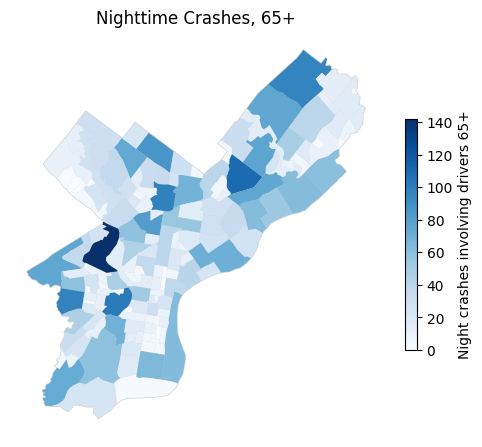

In [10]:
fig = philly_gdf.plot(
    color="white",
    edgecolor="lightgray",
    figsize=(6,6)
)

area_counts.plot(
    ax=fig,
    column="crash_count",
    cmap="Blues",
    legend=True,
    legend_kwds={
        "shrink":0.5,
        "label":"Night crashes involving drivers 65+"
    }
)

fig.axis("off")
fig.set_title("Nighttime Crashes, 65+")

plt.show()

In [11]:
area_counts.sort_values(
    "crash_count", ascending=False
)[["listname","crash_count"]].head(10)

,listname,crash_count
151,West Park,142.0
67,Oxford Circle,110.0
133,University City,102.0
107,Logan,98.0
138,Cobbs Creek,97.0
44,Somerton,96.0
22,West Oak Lane,86.0
93,Tioga,82.0
65,Rhawnhurst,77.0
1,Overbrook,76.0


In [12]:
under65_night = under65_night.dropna(subset=["DEC_LONGITUDE","DEC_LATITUDE"])
under65_sample = under65_night.sample(n=20000, random_state=1)
under65_night_gdf = gpd.GeoDataFrame(
    under65_sample,
    geometry=gpd.points_from_xy(
        under65_sample.DEC_LONGITUDE,
        under65_sample.DEC_LATITUDE
    ),
    crs="EPSG:4326"
)

In [13]:
under65_joined = gpd.sjoin(
    under65_night_gdf,
    philly_gdf,
    predicate="within"
)
area_counts = (
    under65_joined
    .groupby("listname")
    .size()
    .reset_index(name="crash_count")
)
area_counts = philly_gdf.merge(
    area_counts,
    on="listname",
    how="left"
)

area_counts["crash_count"] = area_counts["crash_count"].fillna(0)

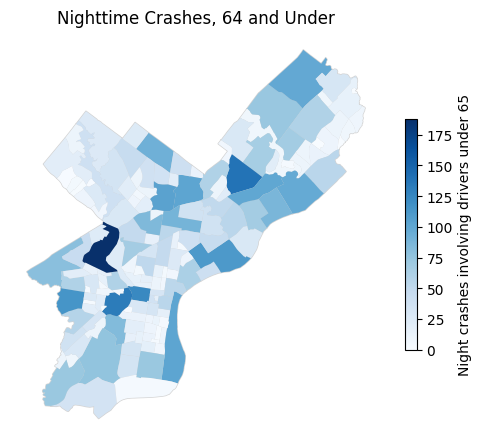

In [14]:
fig = philly_gdf.plot(
    color="white",
    edgecolor="lightgray",
    figsize=(6,6)
)

area_counts.plot(
    ax=fig,
    column="crash_count",
    cmap="Blues",
    legend=True,
    legend_kwds={
        "shrink":0.5,
        "label":"Night crashes involving drivers under 65"
    }
)

fig.axis("off")
fig.set_title("Nighttime Crashes, 64 and Under")

plt.show()

In [15]:
area_counts.sort_values(
    "crash_count", ascending=False
)[["listname","crash_count"]].head(10)

,listname,crash_count
151,West Park,188.0
67,Oxford Circle,139.0
133,University City,133.0
115,Logan Square,124.0
138,Cobbs Creek,115.0
97,Richmond,111.0
107,Logan,104.0
42,Olney,102.0
51,Riverfront,102.0
75,Mayfair,100.0


In [16]:
all_night = all_night.dropna(subset=["DEC_LONGITUDE","DEC_LATITUDE"])
all_night_sample = all_night.sample(n=20000, random_state=1)
all_night_gdf = gpd.GeoDataFrame(
    all_night_sample,
    geometry=gpd.points_from_xy(
        all_night_sample.DEC_LONGITUDE,
        all_night_sample.DEC_LATITUDE
    ),
    crs="EPSG:4326"
)

In [17]:
all_joined = gpd.sjoin(
    all_night_gdf,
    philly_gdf,
    predicate="within"
)
area_counts = (
    older_joined
    .groupby("listname")
    .size()
    .reset_index(name="crash_count")
)
area_counts = philly_gdf.merge(
    area_counts,
    on="listname",
    how="left"
)

area_counts["crash_count"] = area_counts["crash_count"].fillna(0)

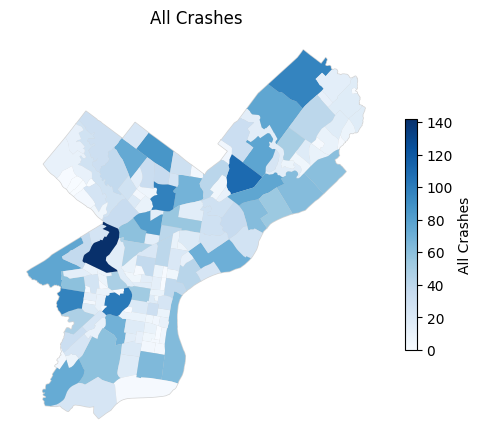

In [18]:
fig = philly_gdf.plot(
    color="white",
    edgecolor="lightgray",
    figsize=(6,6)
)

area_counts.plot(
    ax=fig,
    column="crash_count",
    cmap="Blues",
    legend=True,
    legend_kwds={
        "shrink":0.5,
        "label":"All Crashes"
    }
)

fig.axis("off")
fig.set_title("All Crashes")

plt.show()

In [19]:
area_counts.sort_values(
    "crash_count", ascending=False
)[["listname","crash_count"]].head(10)

,listname,crash_count
151,West Park,142.0
67,Oxford Circle,110.0
133,University City,102.0
107,Logan,98.0
138,Cobbs Creek,97.0
44,Somerton,96.0
22,West Oak Lane,86.0
93,Tioga,82.0
65,Rhawnhurst,77.0
1,Overbrook,76.0


These three lists reveal that nighttime crash locations are fairly consistent across driver age groups, with several Philadelphia neighborhoods appearing repeatedly among the areas with the highest crash counts.

For drivers 65 and older, the largest numbers of nighttime crashes occur in West Park, Oxford Circle, and University City, followed closely by Logan, Cobbs Creek, and Somerton. Many of these neighborhoods are located along major road corridors or near dense residential areas, which may lead to higher traffic volumes even at night.

The list for drivers under 64 looks very similar. West Park, Oxford Circle, and University City again appear at the top, with additional high-crash areas including Logan Square, Richmond, Olney, and Mayfair. This overlap suggests that the geography of crashes is driven more by traffic patterns and road design than by driver age alone.

The overall crash sample closely mirrors the older-driver list, again highlighting West Park, Oxford Circle, University City, Logan, and Cobbs Creek as major crash locations. The consistency across all three lists indicates that certain neighborhoods function as citywide crash hotspots, regardless of driver age.

Overall, the data suggests that while older drivers may face additional challenges when driving at night, they are generally crashing in the same high-traffic areas as younger drivers, rather than in completely different parts of the city.

## The Road's End

Overall, nighttime crash patterns in Philadelphia appear to be driven more by where people are driving than by how old they are. Older drivers do have slightly lower nighttime crash proportions, but when crashes occur they tend to happen in the same high-traffic neighborhoods as younger drivers. Areas like University City, Oxford Circle, and West Park consistently emerge as hotspots, highlighting the role of busy roads and dense activity. In short, the data suggests that the city’s road environment matters just as much as driver age when it comes to nighttime crashes.